<a href="https://colab.research.google.com/github/mohan342/Enhancing-Fraud-Detection-Using-Synthetic-Transactions-Generated-by-CTGAN/blob/main/Copy_of_Enhancing_Fraud_Detection_Using_Synthetic_Transactions_Generated_by_CTGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn sdv

In [ ]:
import pandas as pd

df = pd.read_csv("creditcard.csv.zip")
print(df.head())
print(df.shape)
print(df.columns)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.info())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
1081
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  

In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True))

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


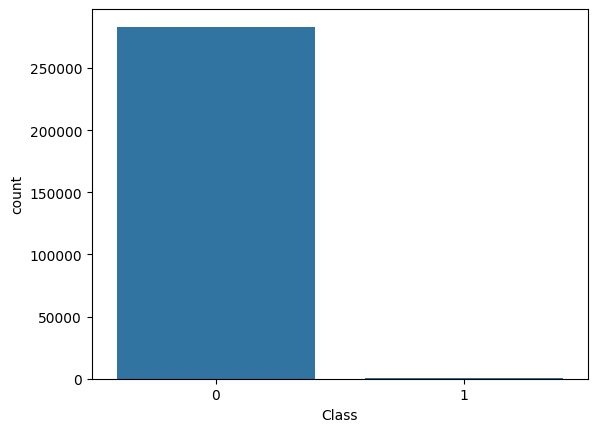

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class", data=df)
plt.show()

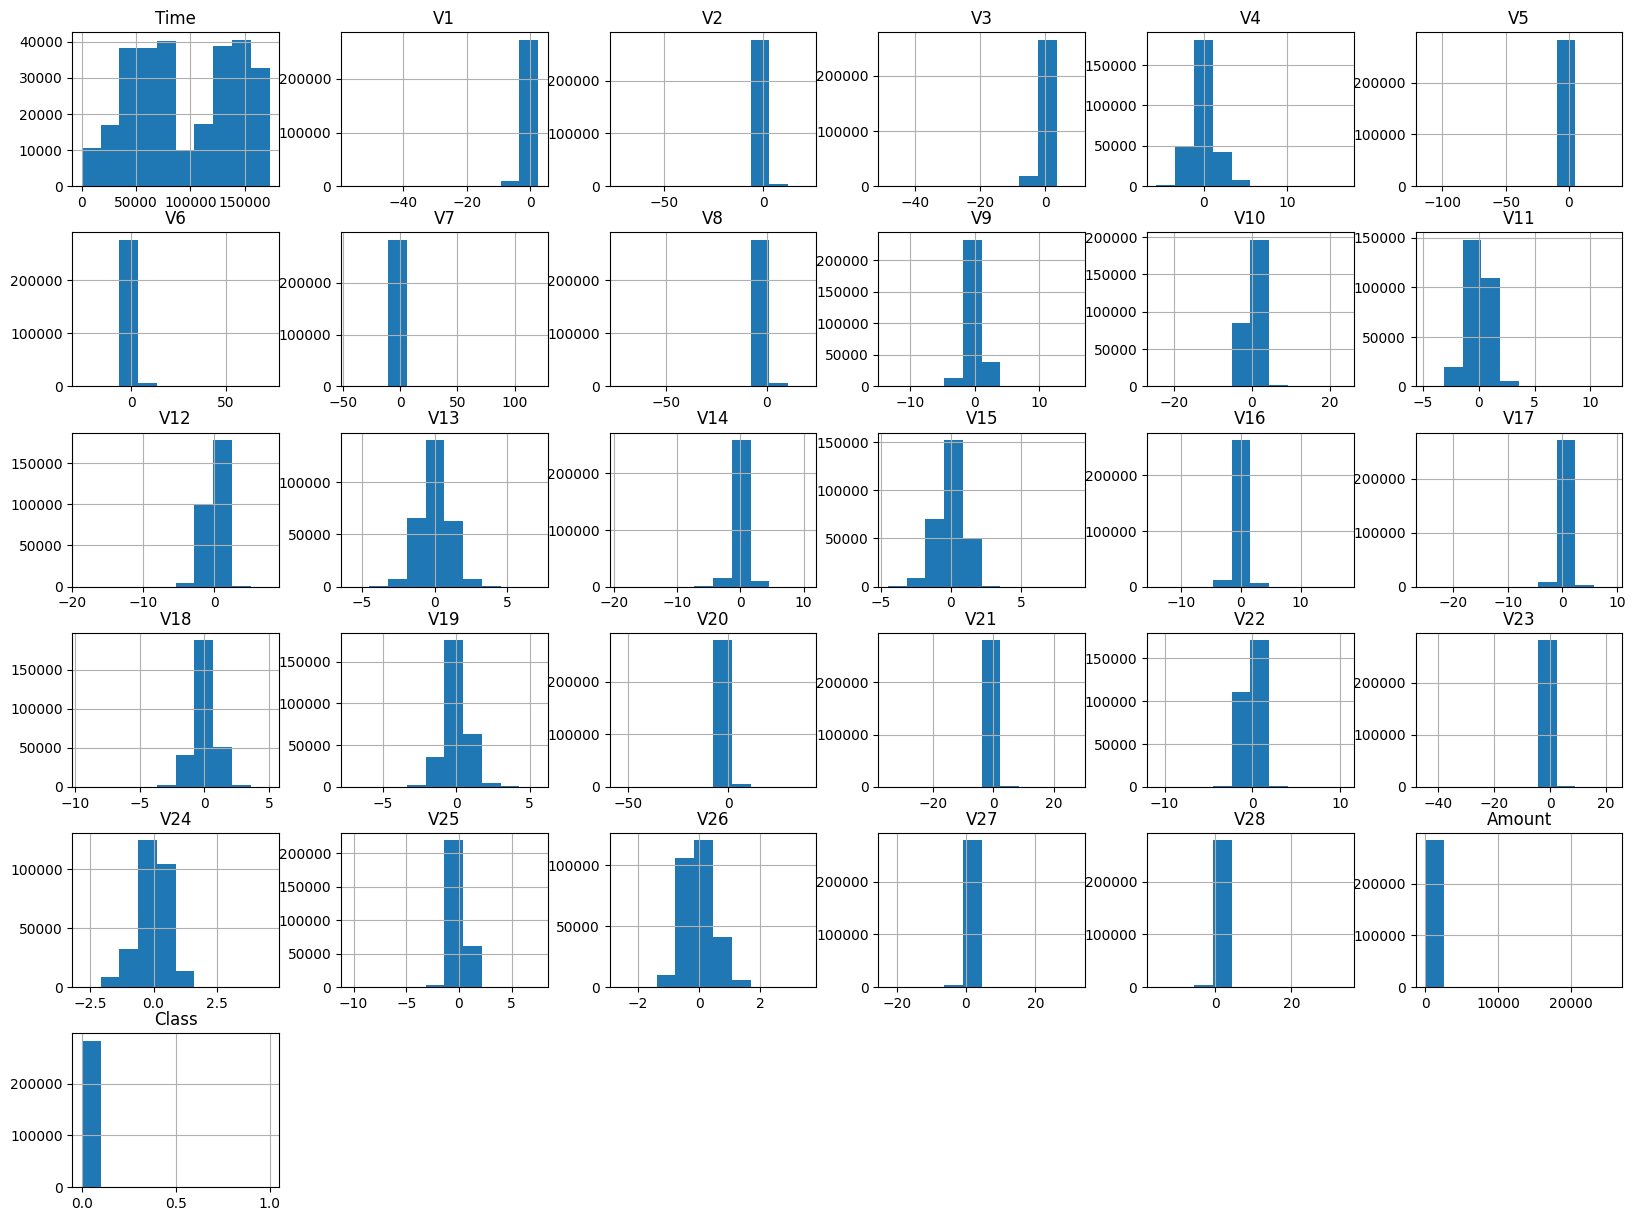

In [ ]:
df.hist(figsize=(20, 15))
plt.show()

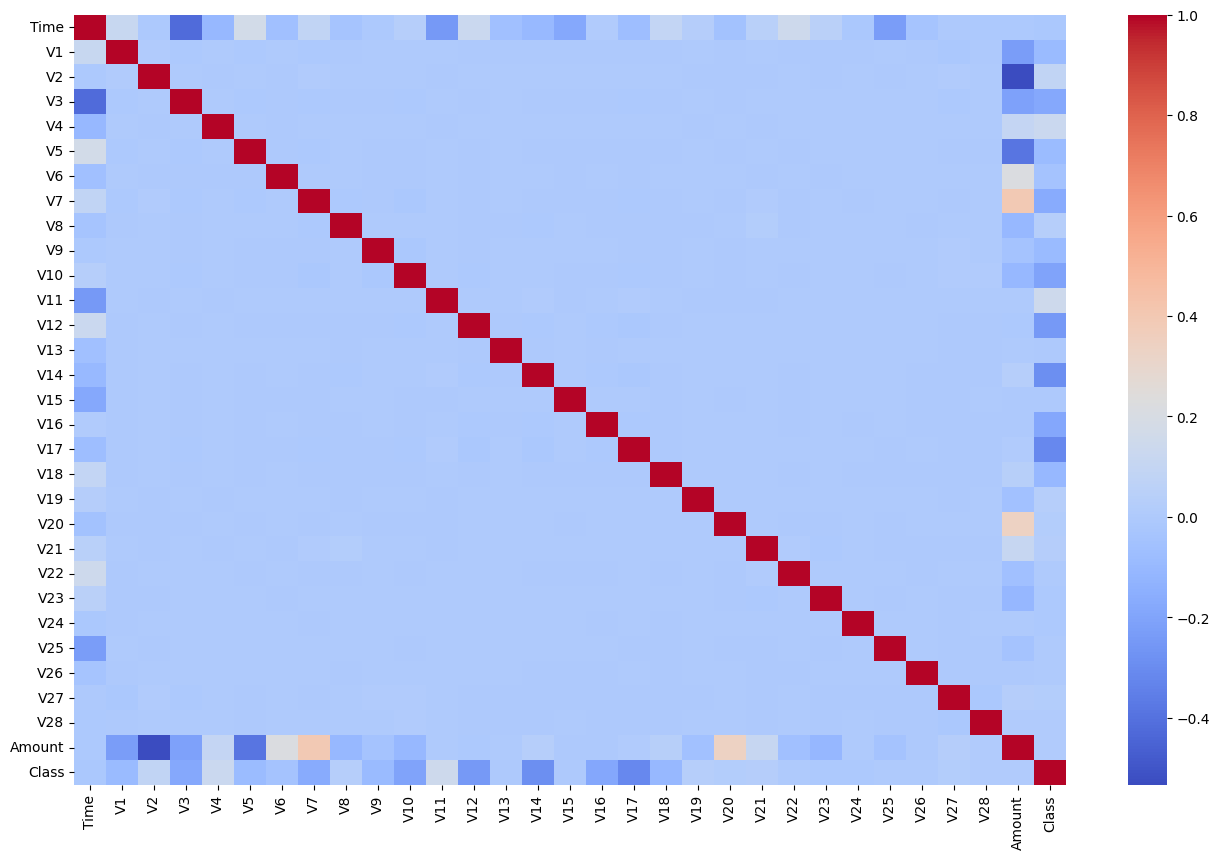

In [ ]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [ ]:
fraud_df = df[df["Class"] == 1].copy()
normal_df = df[df["Class"] == 0].copy()

print(fraud_df.shape)
print(normal_df.shape)

(473, 31)
(283253, 31)


In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=fraud_df)

synthesizer = CTGANSynthesizer(metadata, epochs=100)
synthesizer.fit(fraud_df)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:
synthetic_fraud = synthesizer.sample(num_rows=5000)
print(synthetic_fraud.head())
print(synthetic_fraud.shape)

       Time        V1         V2         V3        V4         V5        V6  \
0  108649.0 -1.944612   0.933369   2.250210  3.045544  -1.814639 -3.406286   
1   44668.0  1.590482   3.663915 -12.318220  0.381474  -0.630440 -6.406267   
2   92950.0 -0.361916  -2.788988   0.980292  0.566970  -0.760826 -1.761005   
3  111041.0 -1.716512  13.957039 -10.142237 -0.344036  -4.715345 -2.309631   
4  122876.0  2.132386  -3.685450   2.250210 -0.490924 -12.902871 -4.925475   

          V7        V8        V9  ...       V21       V22       V23       V24  \
0 -27.278296  1.551743 -0.547533  ...  1.353043 -1.871690 -1.074166 -1.226237   
1   2.560535 -1.012367 -0.965029  ...  0.568496 -1.167202 -0.064474  0.151546   
2  -2.519112 -0.516417 -0.799517  ... -0.526437 -1.036864 -0.496617 -0.425333   
3  -4.085579 -1.436989 -1.859347  ...  2.680963 -3.366373 -0.029428  0.273185   
4  -7.112267  1.161404  3.353525  ...  2.917233 -0.904522 -0.242785 -2.028024   

        V25       V26       V27       V28  A

In [ ]:
augmented_df = pd.concat([df, synthetic_fraud], ignore_index=True)
print(augmented_df["Class"].value_counts())

Class
0    283253
1      5473
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

X = augmented_df.drop("Class", axis=1)
y = augmented_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


joblib.dump(model, "fraud_model.pkl")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
augmented_df.to_csv("augmented_df.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("creditcard.csv.zip")
print(df.shape)
print(df["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(pd.Series(y_resampled).value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [ ]:
balanced_creditcard = X_resampled.copy()
balanced_creditcard["Class"] = y_resampled

balanced_creditcard.to_csv("balanced_creditcard.csv", index=False)
print(balanced_creditcard.head())
print(balanced_creditcard.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
# The model is already saved in cell 'G6qs0bfb-eqr' after fitting.
# This cell is no longer needed to save the model and can be removed or kept empty.

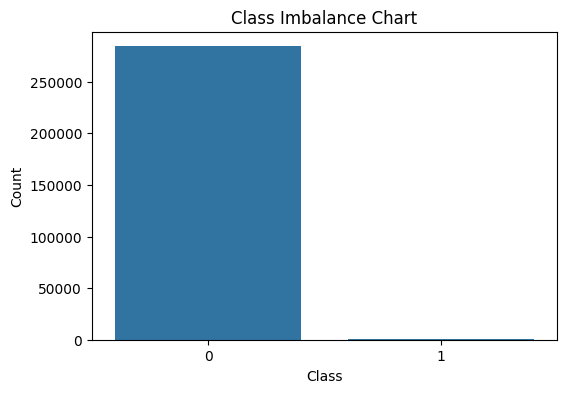

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=df["Class"])
plt.title("Class Imbalance Chart")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
print(X_test.shape)
print(y_test.shape)
print(model.classes_)

(57746, 30)
(57746,)
[array([0, 1])]


In [ ]:
print(balanced_creditcard["Class"].value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


Attempting to load model from 'fraud_model.pkl'.
Model is not fitted or 'fraud_model.pkl' was not found/corrupted. Re-fitting the model now.
Model re-fitted successfully using X_train and y_train.
Train classes: Class
0    226602
1      4378
Name: count, dtype: int64
Test classes: Class
0    56651
1     1095
Name: count, dtype: int64


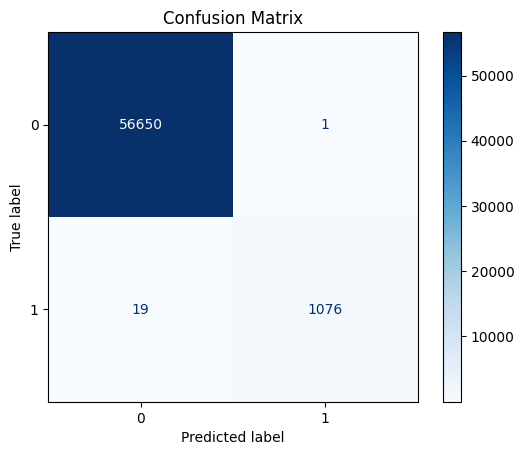

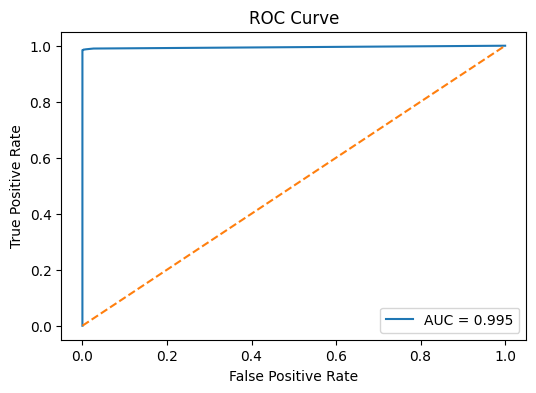

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.validation import check_is_fitted, NotFittedError

model = None
# Attempt to load the trained model
try:
    model = joblib.load("fraud_model.pkl")
    print("Attempting to load model from 'fraud_model.pkl'.")
except FileNotFoundError:
    print("Warning: 'fraud_model.pkl' not found.")
    model = None

# Explicitly check if the model is fitted, even if loading succeeded
# RandomForestClassifier stores its fitted estimators in the 'estimators_' attribute
if model is None or not hasattr(model, 'estimators_') or len(model.estimators_) == 0:
    print("Model is not fitted or 'fraud_model.pkl' was not found/corrupted. Re-fitting the model now.")
    # Re-initialize and fit the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    # X_train and y_train are assumed to be available from previous cells
    if 'X_train' in globals() and 'y_train' in globals():
        model.fit(X_train, y_train)
        print("Model re-fitted successfully using X_train and y_train.")
    else:
        print("Error: X_train or y_train not found. Cannot re-fit model.")
        raise RuntimeError("Model is not fitted and cannot be re-fitted due to missing training data.")
else:
    print("Model loaded and confirmed as fitted.")


print("Train classes:", pd.Series(y_train).value_counts())
print("Test classes:", pd.Series(y_test).value_counts())

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

if len(model.classes_) > 1:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
else:
    print("ROC cannot be plotted because the model has only one class.")

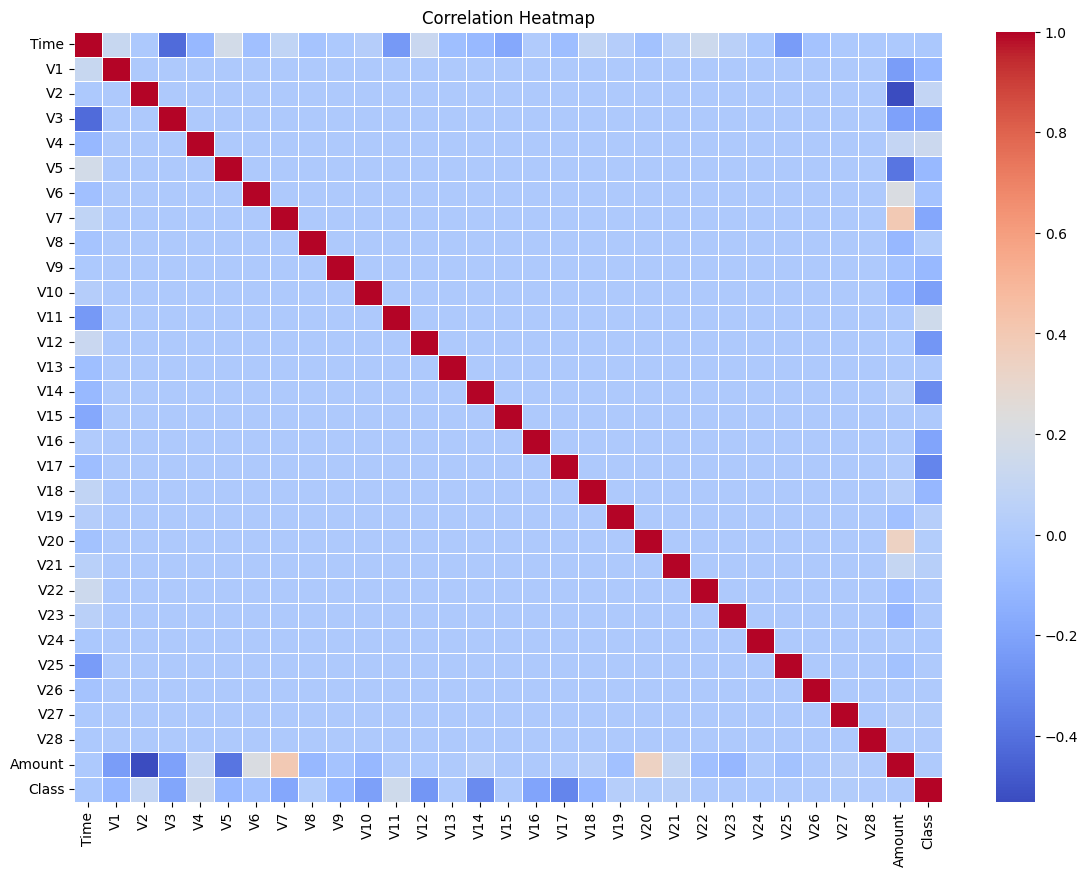

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

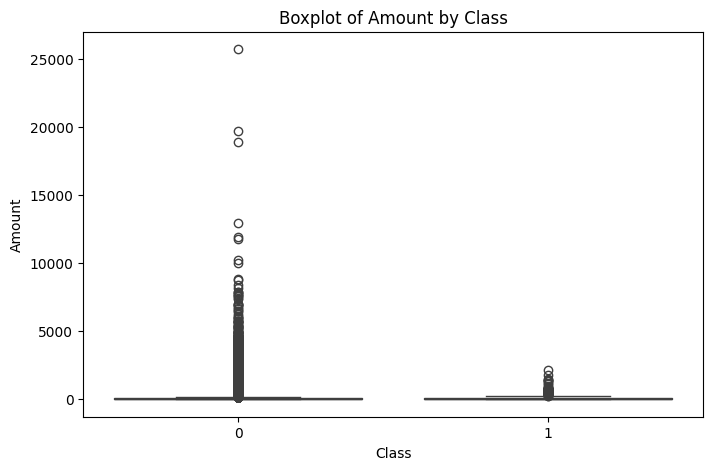

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Class"], y=df["Amount"])
plt.title("Boxplot of Amount by Class")
plt.show()

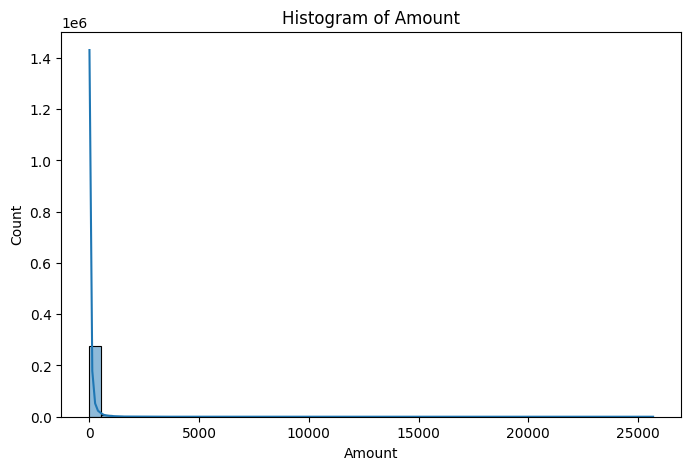

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Histogram of Amount")
plt.show()

In [ ]:
!pip install streamlit -q
!npm install localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 45.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 3s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠙

In [ ]:
%%writefile app.py
import streamlit as st

st.title("Fraud Detection App")
st.write("Streamlit app running from Google Colab")

Writing app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙your url is: https://deep-eyes-repair.loca.lt
^C


In [ ]:
print("balanced_creditcard" in globals())
print("augmented_df" in globals())

False
False
